In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score


plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor":  (0.12 , 0.12, 0.12, 1),
    "axes.facecolor": (0.12 , 0.12, 0.12, 1),
})

# 1. Fonctions

In [15]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)
    b = np.random.randn(1)
    return (W, b)

In [16]:
def model(X, W, b):
    Z = X.dot(W) + b
    # print(Z.min())
    A = 1 / (1 + np.exp(-Z))
    return A

In [17]:
def log_loss(A, y):
    epsilon = 1e-15
    return 1 / len(y) * np.sum(-y * np.log(A + epsilon) - (1 - y) * np.log(1 - A + epsilon))

In [18]:
def gradients(A, X, y):
    dW = 1 / len(y) * np.dot(X.T, A - y)
    db = 1 / len(y) * np.sum(A - y)
    return (dW, db)

In [19]:
def update(dW, db, W, b, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

In [20]:
def predict(X, W, b):
    A = model(X, W, b)
    # print(A)
    return A >= 0.5

In [21]:
from tqdm import tqdm

In [22]:
def artificial_neuron(X_train, y_train, X_test, y_test, learning_rate = 0.1, n_iter = 100):
    # initialisation W, b
    W, b = initialisation(X_train)

    train_loss = []
    train_acc = []
    test_loss = []
    test_acc = []

    for i in tqdm(range(n_iter)):
        A = model(X_train, W, b)

        if i %10 == 0:
            # Train
            train_loss.append(log_loss(A, y_train))
            y_pred = predict(X_train, W, b)
            train_acc.append(accuracy_score(y_train, y_pred))

            # Test
            A_test = model(X_test, W, b)
            test_loss.append(log_loss(A_test, y_test))
            y_pred = predict(X_test, W, b)
            test_acc.append(accuracy_score(y_test, y_pred))

        # mise a jour
        dW, db = gradients(A, X_train, y_train)
        W, b = update(dW, db, W, b, learning_rate)


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.plot(test_loss, label='test loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train acc')
    plt.plot(test_acc, label='test acc')
    plt.legend()
    plt.show()

    return (W, b)

# Dataset

dimensions de X: (100, 2)
dimensions de y: (100, 1)


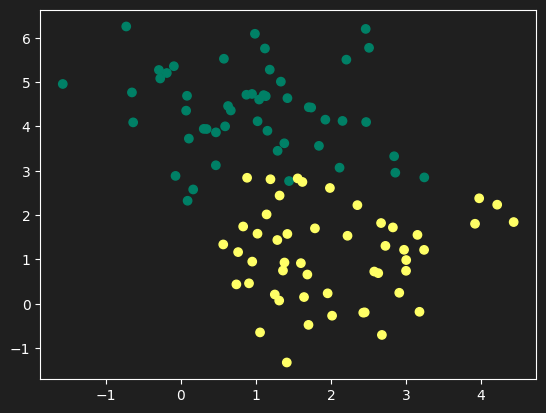

In [23]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

print('dimensions de X:', X.shape)
print('dimensions de y:', y.shape)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

# Application Chat vs Chien

In [24]:
# !pip install h5py
from utilities import *

In [25]:
X_train, y_train, X_test, y_test = load_data()

In [26]:
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train, return_counts=True))

(1000, 64, 64)
(1000, 1)
(array([0., 1.]), array([500, 500]))


In [27]:
print(X_test.shape)
print(y_test.shape)
print(np.unique(y_test, return_counts=True))

(200, 64, 64)
(200, 1)
(array([0., 1.]), array([100, 100]))


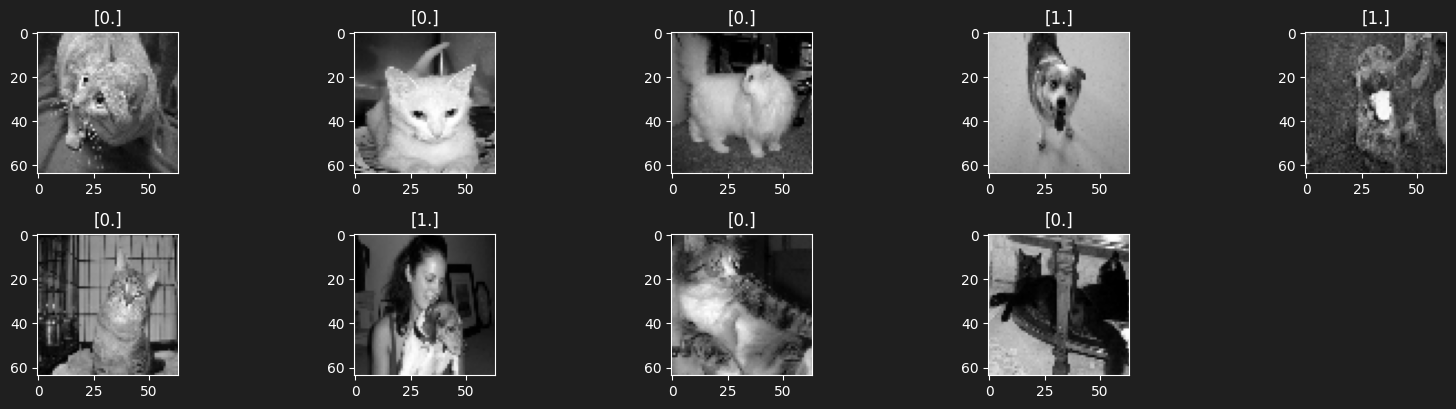

In [28]:
plt.figure(figsize=(16, 8))
for i in range(1, 10):
    plt.subplot(4, 5, i)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.tight_layout()
plt.show()

# Entrainement du Modele

In [29]:
X_train_reshape = X_train.reshape(X_train.shape[0], -1) / X_train.max()
X_train_reshape.shape

(1000, 4096)

In [30]:
X_test_reshape = X_test.reshape(X_test.shape[0], -1) / X_train.max()
X_test_reshape.shape

(200, 4096)

  0%|          | 9/10000 [00:00<01:57, 84.68it/s]

100%|██████████| 10000/10000 [00:27<00:00, 366.67it/s]


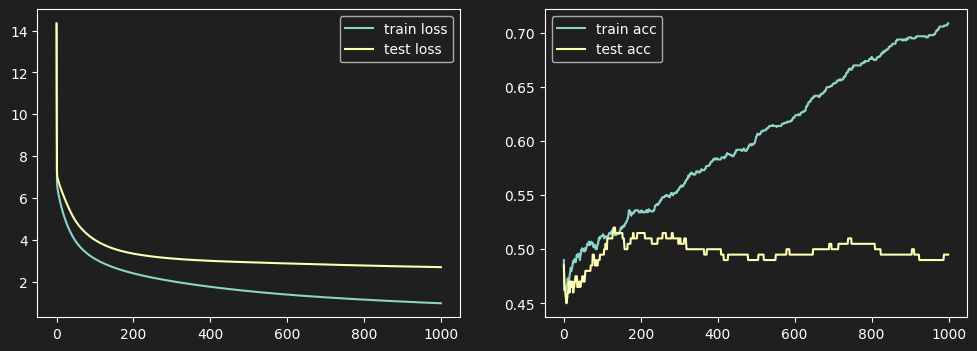

In [31]:
W, b = artificial_neuron(X_train_reshape, y_train, X_test_reshape, y_test, learning_rate = 0.01, n_iter=10000)

on utilise Min Max scaler pour eviter davoir un overflow dans l'EXp et on utilise un Espilon dans le Log pour toujours avoir un truc strictement positif.


## Reseau de neurones à deux couches

$$
z_1 = w_{11}x_1 + w_{12}x_2 + b_1
$$
$$
a_1 = \frac{1}{1 + e^{-z_1}}
$$

$$
z_2 = w_{21}x_1 + w_{22}x_2 + b_2
$$
$$
a_2 = \frac{1}{1 + e^{-z_2}}
$$

## Pour résumer :

**1.** On note $w_{ij}$ le paramètre associé au neurone $i$ et provenant de l'entrée $j$

**2.** On note $^{[C]}$ le numéro de la couche C sur laquelle on travaille : $z^{[1]}$, $z^{[2]}$, etc.

**3.** Pour calculer les valeurs $z$ d'une couche $^{[C]}$ on utilise les activations $a$ de la couche $^{[C-1]}$

$$z_1^{[2]} = w_{11}^{[2]} a_1^{[1]} + w_{12}^{[2]} a_2^{[1]} + b^{[2]}$$

$$Z^{[1]} = \begin{bmatrix} x_1^{(1)} & x_2^{(1)} \\ x_1^{(2)} & x_2^{(2)} \\ \vdots & \vdots \\ x_1^{(m)} & x_2^{(m)} \end{bmatrix} \cdot \begin{bmatrix} w_{11}^{[1]} & w_{21}^{[1]} \\ w_{12}^{[1]} & w_{22}^{[1]} \end{bmatrix} + \begin{bmatrix} b_1^{[1]} & b_2^{[1]} \end{bmatrix}$$

$$= \begin{bmatrix} x_1^{(1)}w_{11}^{[1]} + x_2^{(1)}w_{12}^{[1]} + b_1^{[1]} & x_1^{(1)}w_{21}^{[1]} + x_2^{(1)}w_{22}^{[1]} + b_2^{[1]} \\ x_1^{(2)}w_{11}^{[1]} + x_2^{(2)}w_{12}^{[1]} + b_1^{[1]} & x_1^{(2)}w_{21}^{[1]} + x_2^{(2)}w_{22}^{[1]} + b_2^{[1]} \\ \vdots & \vdots \\ x_1^{(m)}w_{11}^{[1]} + x_2^{(m)}w_{12}^{[1]} + b_1^{[1]} & x_1^{(m)}w_{21}^{[1]} + x_2^{(m)}w_{22}^{[1]} + b_2^{[1]} \end{bmatrix}$$

$$\underbrace{X \in \mathbb{R}^{m \times 2}} \quad \underbrace{W^{[1]} \in \mathbb{R}^{2 \times 2}} \quad \underbrace{b^{[1]} \in \mathbb{R}^{1 \times 2}} \quad \underbrace{Z^{[1]} \in \mathbb{R}^{m \times 2}}$$

$$A^{[1]} = \frac{1}{1 + e^{-Z^{[1]}}} = \begin{bmatrix} a_1^{[1](1)} & a_1^{[1](2)} & \cdots & a_1^{[1](m)} \\ a_2^{[1](1)} & a_2^{[1](2)} & \cdots & a_2^{[1](m)} \\ a_3^{[1](1)} & a_3^{[1](2)} & \cdots & a_3^{[1](m)} \end{bmatrix}$$

$$Z^{[2]} = W^{[2]} \cdot A^{[1]} + b^{[2]}$$

$$W^{[2]} \in \mathbb{R}^{(n^{[2]} \times n^{[1]})}$$

$$b^{[2]} \in \mathbb{R}^{(n^{[2]} \times 1)}$$

$n^{[1]}$ : nombre de neurones dans la couche $[1]$

$n^{[2]}$ : nombre de neurones dans la couche $[2]$

# Experience sur la Normalisation

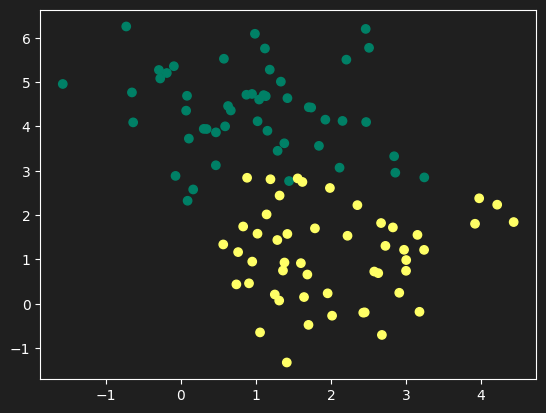

In [32]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
X[:, 1] = X[:, 1] * 1

y = y.reshape(y.shape[0], 1)

plt.scatter(X[:,0], X[:, 1], c=y, cmap='summer')
plt.show()

In [33]:
def artificial_neuron_2(X, y, learning_rate=0.1, n_iter=1000):

  W, b = initialisation(X)
  W[0], W[1] = -7.5, 7.5

  nb = 1
  j=0
  history = np.zeros((n_iter // nb, 5))

  A = model(X, W, b)
  Loss = []
  

  Params1 = [W[0]]
  Params2 = [W[1]]
  Loss.append(log_loss(y, A))
  
  # Training
  for i in range(n_iter):
    A = model(X, W, b)
    Loss.append(log_loss(y, A))
    Params1.append(W[0])
    Params2.append(W[1])
    dW, db = gradients(A, X, y)
    W, b = update(dW, db, W, b, learning_rate = learning_rate)

    if (i % nb == 0):  
      history[j, 0] = W[0]
      history[j, 1] = W[1]
      history[j, 2] = b
      history[j, 3] = i
      history[j, 4] = log_loss(y, A)
      j +=1

  plt.plot(Loss)
  plt.show()

  return history, b, Loss, Params1, Params2

/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_4980/1382749313.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  history[j, 0] = W[0]
/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_4980/1382749313.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  history[j, 1] = W[1]
/var/folders/gg/dm5j6jg565j0bblwgpt9ggsw0000gn/T/ipykernel_4980/1382749313.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  history[j, 2] = b


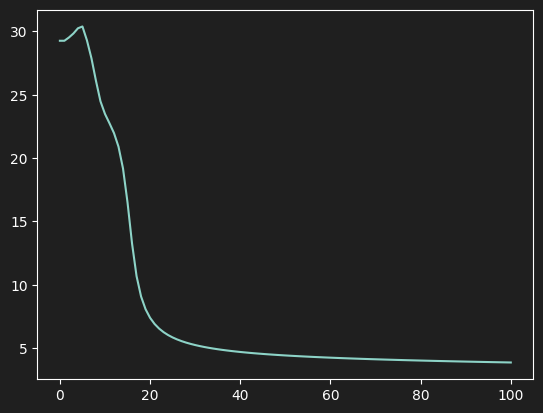

In [34]:
history, b, Loss, Params1, Params2 = artificial_neuron_2(X, y, learning_rate=0.6, n_iter=100)

In [35]:
lim = 15
h = 100
W1 = np.linspace(-lim, lim, h)
W2 = np.linspace(-lim, lim, h)

W11, W22 = np.meshgrid(W1, W2)

W_final = np.c_[W11.ravel(), W22.ravel()].T
W_final.shape


(2, 10000)

In [36]:
Z = X.dot(W_final) + b
A = 1 / (1 + np.exp(-Z))

epsilon = 1e-15
L = 1 / len(y) * np.sum(-y * np.log(A + epsilon) - (1 - y) * np.log(1 - A + epsilon), axis=0).reshape(W11.shape)
L.shape

(100, 100)

In [37]:
from matplotlib.animation import FuncAnimation

In [38]:
def animate(params):
  W0 = params[0]
  W1 = params[1]
  b = params[2]
  i = params[3]
  loss = params[4]
  

  # ax[0].clear() # frontiere de décision
  # ax[1].clear() # sigmoide
  # ax[2].clear() # fonction Cout
  
  ax[0].contourf(W11, W22, L, 20, cmap='magma', zorder=-1)
  ax[0].scatter(Params1[int(i)], Params2[int(i)], c='r', marker='x', s=50, zorder=1)
  ax[0].plot(Params1[0:int(i)], Params2[0:int(i)], lw=3, c='r', zorder=1)

  ax[1].plot(Loss[0:int(i)], lw=3, c='white')
  ax[1].set_xlim(0, len(Params1))
  ax[1].set_ylim(min(Loss) - 2, max(Loss) + 2)
  

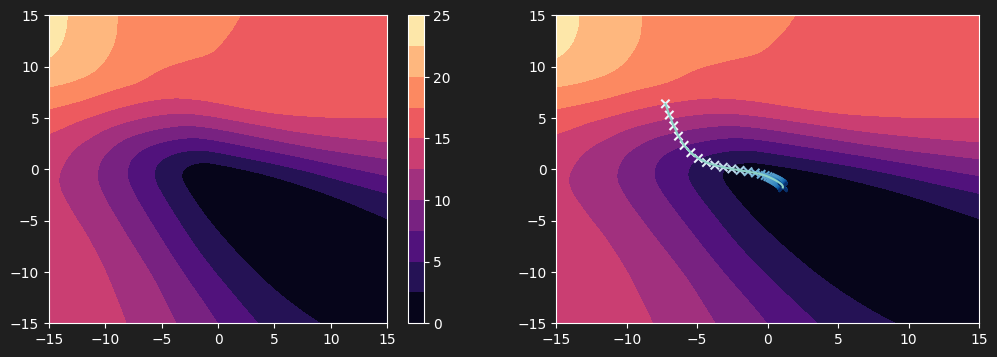

In [39]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.contourf(W11, W22, L, 10, cmap='magma')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.contourf(W11, W22, L, 10, cmap='magma')
plt.scatter(history[:, 0], history[:, 1], c=history[:, 2], cmap='Blues', marker='x')
plt.plot(history[:, 0], history[:, 1])
# plt.plot(history[:, 0], history[:, 1], c='r')
# plt.colorbar()

RuntimeError: Requested MovieWriter (ffmpeg) not available

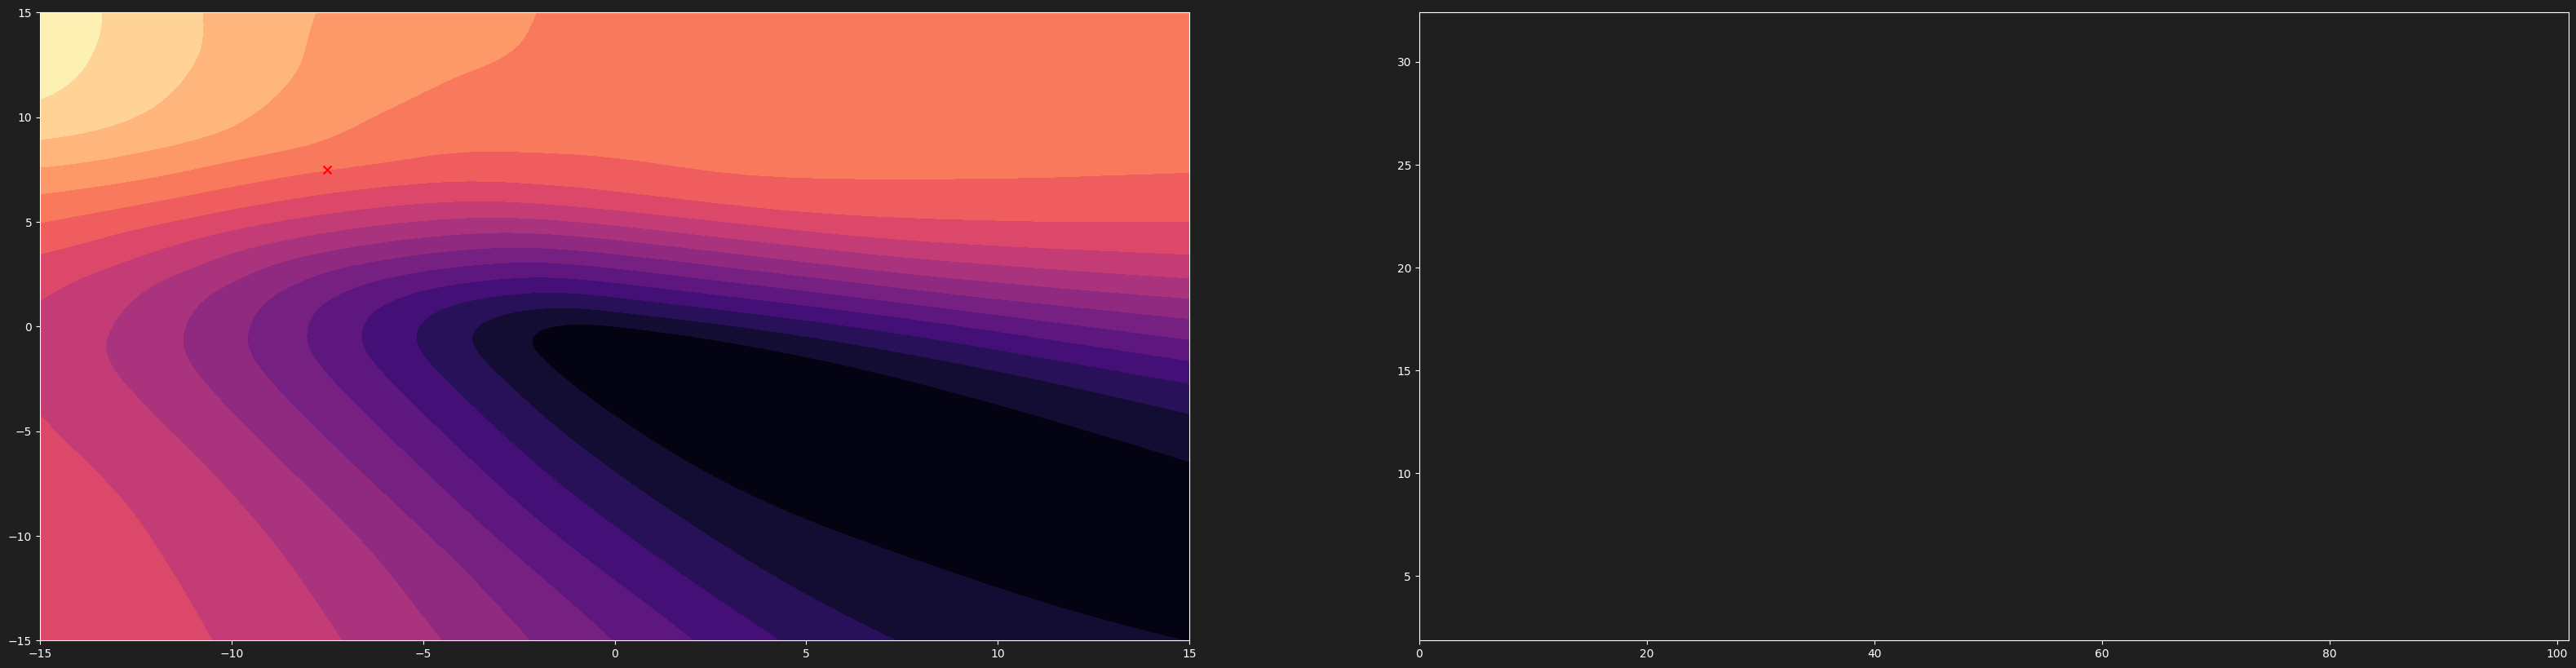

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(40, 10))
ani = FuncAnimation(fig, animate, frames=history, interval=10, repeat=False)

import matplotlib.animation as animation
Writer = animation.writers['ffmpeg']
writer = Writer(fps=10, metadata=dict(artist='Me'), bitrate=3200)
ani.save('animation3.mp4', writer=writer)

In [ ]:
import plotly.graph_objects as go

fig = (go.Figure(data=[go.Surface(z=L, x=W11, y=W22, opacity = 1)]))

fig.update_layout(template= "plotly_dark", margin=dict(l=0, r=0, b=0, t=0))
fig.layout.scene.camera.projection.type = "orthographic"
fig.show()